## Imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

## Load and Transform Fashion-MNIST Dataset

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.47MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.14MB/s]


## Split Dataset and Create DataLoaders

In [5]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Build MLP Model Architecture

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

criterion = nn.CrossEntropyLoss()

## Train Model 1

In [7]:
train_losses = []
train_accuracies = []
val_losses = []

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):

    model.train()

    correct, total, loss_sum = 0, 0, 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

    epoch_loss = loss_sum / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()

    val_loss = 0

    with torch.no_grad():
      for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_losses.append(val_loss / len(test_loader))

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Acc: {epoch_acc:.2f}%"
    )

Epoch 1 | Loss: 0.6504 | Acc: 76.52%
Epoch 2 | Loss: 0.4437 | Acc: 84.14%
Epoch 3 | Loss: 0.4043 | Acc: 85.08%
Epoch 4 | Loss: 0.3796 | Acc: 86.16%
Epoch 5 | Loss: 0.3654 | Acc: 86.73%
Epoch 6 | Loss: 0.3532 | Acc: 86.92%
Epoch 7 | Loss: 0.3395 | Acc: 87.48%
Epoch 8 | Loss: 0.3343 | Acc: 87.65%
Epoch 9 | Loss: 0.3254 | Acc: 87.85%
Epoch 10 | Loss: 0.3193 | Acc: 88.11%


## Evaluate Model 1

In [8]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
avg_loss = test_loss / len(test_loader)

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Loss: {avg_loss:.4f}")

Test Accuracy: 87.18%
Test Loss: 0.3534


## Train Model 2

In [9]:
model2 = MLP()

criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

num_epochs = 10

for epoch in range(num_epochs):

    model2.train()

    correct, total, loss_sum = 0, 0, 0

    for images, labels in train_loader:

        optimizer2.zero_grad()

        outputs = model2(images)
        loss = criterion2(outputs, labels)

        loss.backward()
        optimizer2.step()

        loss_sum += loss.item()

        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    print(
        f"Exp2 Epoch {epoch+1} | "
        f"Loss: {loss_sum/len(train_loader):.4f} | "
        f"Acc: {100*correct/total:.2f}%"
    )

Exp2 Epoch 1 | Loss: 0.6518 | Acc: 76.29%
Exp2 Epoch 2 | Loss: 0.5486 | Acc: 80.06%
Exp2 Epoch 3 | Loss: 0.5226 | Acc: 81.43%
Exp2 Epoch 4 | Loss: 0.5058 | Acc: 81.97%
Exp2 Epoch 5 | Loss: 0.4984 | Acc: 82.33%
Exp2 Epoch 6 | Loss: 0.4861 | Acc: 82.63%
Exp2 Epoch 7 | Loss: 0.4853 | Acc: 82.59%
Exp2 Epoch 8 | Loss: 0.4748 | Acc: 83.17%
Exp2 Epoch 9 | Loss: 0.4758 | Acc: 83.13%
Exp2 Epoch 10 | Loss: 0.4581 | Acc: 83.61%


## Evaluate Model 2

In [10]:
model2.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model2(images)
        loss = criterion2(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
avg_loss = test_loss / len(test_loader)

print("Model 2 Results:")
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Loss: {avg_loss:.4f}")

Model 2 Results:
Test Accuracy: 85.07%
Test Loss: 0.4299


## Visualization

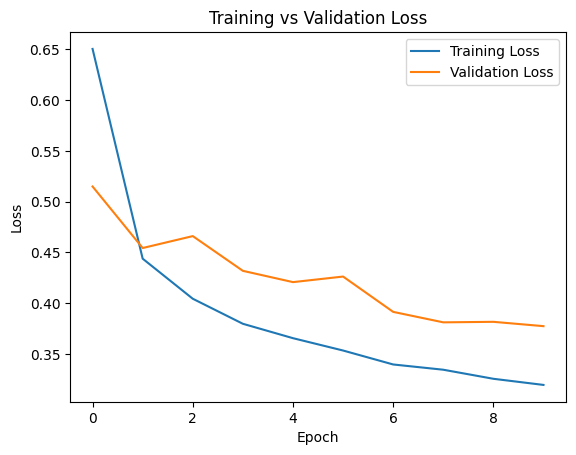

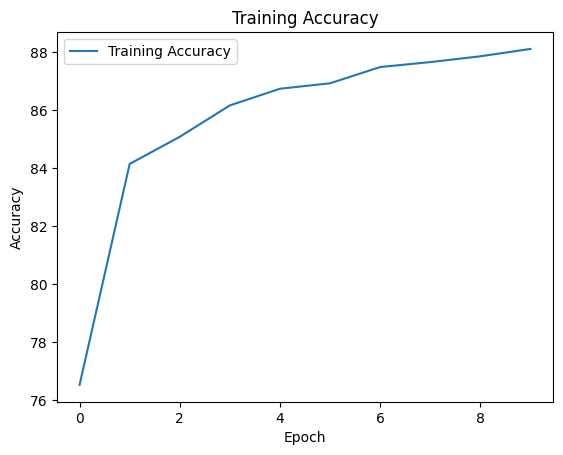

In [11]:

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

plt.plot(train_accuracies, label="Training Accuracy")

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()